# Begin

In [1]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
import re
import pickle
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
from io import BytesIO

from tqdm.notebook import tqdm

import numpy as np
import cupy as cp
import einops
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from logging_utils import *
from image_utils import *
from model_registry import *
from basis_pursuit import *

# Init

In [2]:
ArrayUtils.init()
LOG = Logging.get()
RNG = np.random.default_rng()

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, mnist_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/15_transformer',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/15_transformer',
 'run_path': '/home/misha/dev/mine/neurovision/run/15_transformer',
 'self_fname': '/home/misha/dev/mine/neurovision/15_transformer/15_dataset.ipynb',
 'self_name': '15_dataset',
 'subproject_name': '15_transformer',
 'is_cuda': True,
 'cuda_device': 'cuda',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [3]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    vocab_model_name: str = None
    vocab_model_version: int = None
    vocab_hypers: dict = None
    vocab: object = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42

# Bootstrap

In [4]:
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

MODEL_REGISTRY = ModelRegistry(maven_group_id=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')

Random seed=42


# Vocab

## Configure

In [5]:
HP.vocab_model_name = '15_vocab_02'
HP.vocab_model_version = 5
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'vocab_model_name': '15_vocab_02',
 'vocab_model_version': 5,
 'vocab_hypers': None,
 'vocab': None}


## Download

In [6]:
content = MODEL_REGISTRY.get_asset_content(HP.vocab_model_name, HP.vocab_model_version, asset_ext='json', asset_classifier='meta')
meta = json.loads(content.decode('utf-8'))
HP.vocab_hypers = meta['hypers']
HP.vocab = MODEL_REGISTRY.get_asset_content(HP.vocab_model_name, HP.vocab_model_version, asset_ext='npy', asset_classifier='vocab')
HP.vocab = np.load(BytesIO(HP.vocab))

# Images

## Load

In [7]:
IMAGES, _ = get_mnist_images(CONFIG.mnist_path, 'TRAIN')
IMAGES, scaler = preprocess_images(IMAGES, HP.vocab_hypers['images_preprocessing'])

## Decode

### Single

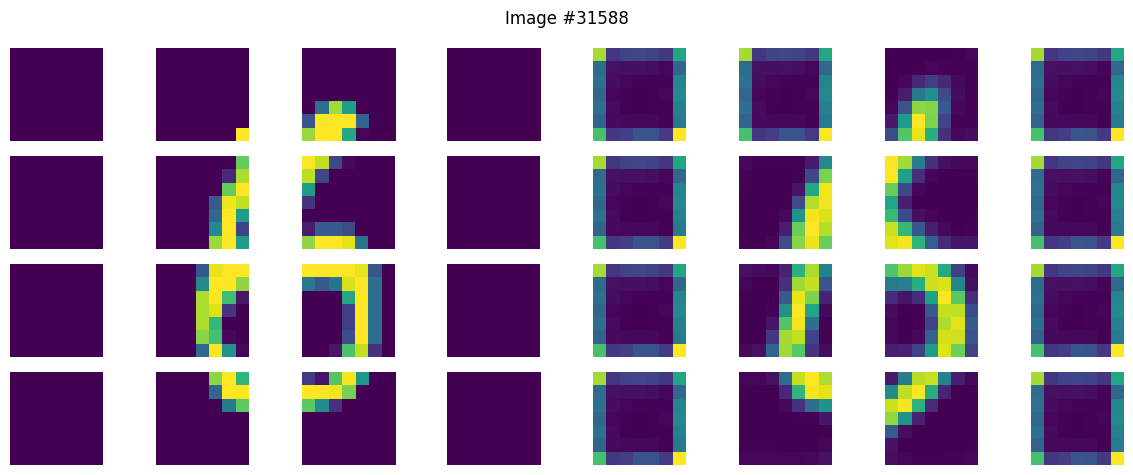

In [20]:
image_ind = RNG.choice(len(IMAGES))
patch_size = HP.vocab_hypers['patch_size']
patches = F.unfold(torch.tensor(einops.rearrange(IMAGES[image_ind], 'h w -> 1 h w')), kernel_size=patch_size, stride=patch_size)
patches_z = bp_batch_solo(einops.rearrange(patches, 'hw p -> p hw'), HP.vocab.T)
patches_z = einops.rearrange(patches_z, '(x y) z-> x y z', x=IMAGES[0].shape[0] // patch_size)
patches = einops.rearrange(patches, '(h w) (x y) -> x y h w', x=IMAGES[0].shape[0] // patch_size, h=patch_size)
fig, axes = plt.subplots(patches.shape[0], patches.shape[1] * 2) # left columns show original patches, right columns - from vocab (after basis pursuit)
fig.set_figwidth(12)
for ax in axes.ravel(): ax.set_axis_off()
fig.suptitle(f'Image #{image_ind}')

for axes_row, patches_row in zip(axes, patches):
    for ax, patch in zip(axes_row, patches_row):
        ax.imshow(patch)

for axes_row, patches_z_row in zip(axes, patches_z):
    for ax, patch_z in zip(axes_row[patches.shape[0]:], patches_z_row):
        vocab_item = HP.vocab[np.argmax(patch_z)]
        ax.imshow(ArrayUtils.v2sm(vocab_item))

fig.tight_layout()

In [ ]:
ПЕРЕФОРМ словарь с учётом ограничения, что айтем при uninorm должен быть 0..1?

In [21]:
vocab_item

array([ 6.8963259e-03,  1.1905420e-03,  1.5581939e-03,  1.6267947e-03,
        1.5733588e-03,  1.2414604e-03,  4.7108801e-03,  2.7666045e-03,
        3.0523018e-04,  2.5759940e-04,  2.9323917e-04,  2.3732652e-04,
        6.0343562e-05,  2.5785079e-03,  2.9246756e-03,  1.9356835e-04,
        6.8927489e-05,  1.4467830e-06,  1.8438661e-05, -2.1435822e-06,
        3.5993829e-03,  2.5964868e-03,  6.7930559e-05,  1.4340019e-05,
       -4.4239350e-05, -1.1304749e-05,  5.8845642e-05,  3.7208502e-03,
        2.8633517e-03,  1.5022747e-04, -1.2160093e-05, -7.0122405e-05,
       -3.0173331e-05, -9.6167978e-06,  3.4703838e-03,  2.4848159e-03,
        1.2652593e-04,  9.6949327e-05,  1.0358191e-04,  1.0625108e-04,
       -2.8866127e-05,  3.2587552e-03,  5.6200735e-03,  1.2292718e-03,
        1.4162933e-03,  2.0723133e-03,  1.9888878e-03,  1.2671388e-03,
        7.9721780e-03], dtype=float32)

### Batch

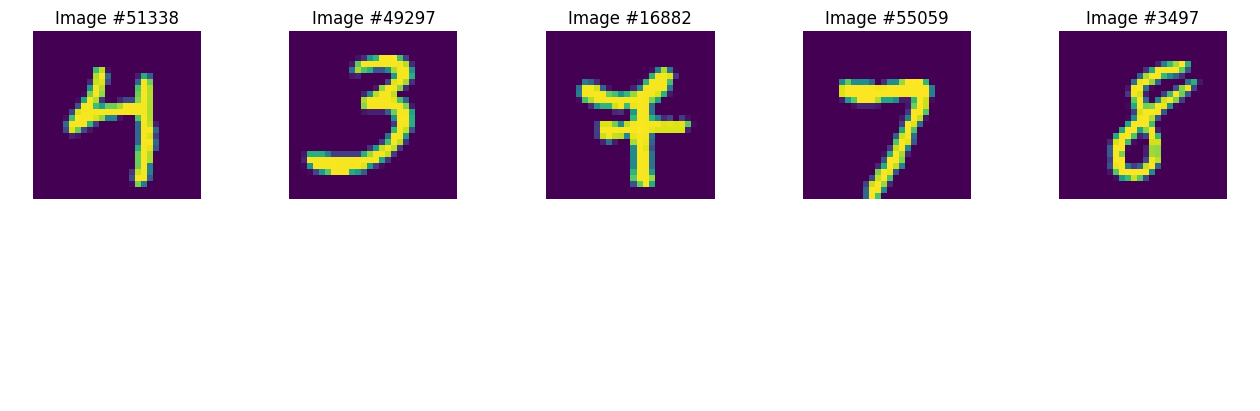

In [25]:
patch_size = HP.vocab_hypers['patch_size']
image_inds = RNG.choice(len(IMAGES), 5, replace=False)
fig, axes = plt.subplots(2, len(image_inds))
fig.set_figwidth(16)
# fig.set_figheight(len(image_inds) * 2)
for ax in axes.ravel(): ax.set_axis_off()

for image_ind, (ax1, ax2) in zip(image_inds, axes.T):
    image = IMAGES[image_ind]
    ax1.set_title(f'Image #{image_ind}')
    ax1.imshow(image)

    patches = F.unfold(torch.tensor(einops.rearrange(image, 'h w -> 1 h w')), kernel_size=patch_size, stride=patch_size)
    patches_z = bp_batch_solo(einops.rearrange(patches, 'hw p -> p hw'), HP.vocab.T)
    patches_z = einops.rearrange(patches_z, '(x y) z-> x y z', x=image.shape[0] // patch_size)

    НАДО СОБРАТЬ ВОЕДИНО КАРТИНКУ из vocab_item в цикле
    vocab_item = HP.vocab[np.argmax(patch_z)]
    ax2.imshow(ArrayUtils.v2sm(vocab_item))    